## 1. Import Thư viện
### Import `DecisionTreeRegressor` từ thư viện `sklearn.tree`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics

# Cài đặt phong cách đồ thị
sns.set_theme(style="whitegrid")

## 2. Đọc Dữ Liệu
Thay vì tải về máy,  chuẩn bị một đường link thô chứa đúng bộ dữ liệu California Housing.  đọc trực tiếp vào Pandas.

In [2]:
# Link raw chứa dữ liệu California Housing Prices
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

# Đọc dữ liệu
df = pd.read_csv(url)

# Xem 5 dòng đầu tiên
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Tiền xử lý dữ liệu (Data Preprocessing)
Trong thực tế, dữ liệu hiếm khi hoàn hảo. Với bộ dữ liệu này:
1. **Thiếu dữ liệu:** Cột `total_bedrooms` thường bị thiếu một vài giá trị (NaN). Chúng ta sẽ lấp đầy các ô trống này bằng **giá trị trung vị (median)** của chính cột đó.
2. **Dữ liệu chữ:** Cột `ocean_proximity` (Gần biển) là dạng chữ (như 'NEAR BAY', 'INLAND'). Ta phải dùng `pd.get_dummies` để biến chúng thành các cột số 0 và 1 cho máy tính hiểu.

In [3]:
# 1. Kiểm tra dữ liệu thiếu
print("Số lượng dữ liệu thiếu trước khi xử lý:\n", df.isnull().sum())

# Điền giá trị trung vị vào các ô trống của cột 'total_bedrooms'
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

print("\nSố lượng dữ liệu thiếu sau khi xử lý: ", df['total_bedrooms'].isnull().sum())

# 2. Mã hóa biến phân loại 'ocean_proximity' thành số
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("\nDữ liệu sau khi mã hóa:")
display(df.head())

Số lượng dữ liệu thiếu trước khi xử lý:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Số lượng dữ liệu thiếu sau khi xử lý:  0

Dữ liệu sau khi mã hóa:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## 4. Tách Biến và Chia Tập Dữ liệu
* **Biến mục tiêu (y):** `median_house_value` (Giá nhà trung bình).
* **Các đặc trưng (X):** Tất cả các cột còn lại.
* Ta sẽ chia dữ liệu theo tỉ lệ 80% để học (Train) và 20% để thi (Test).

In [4]:
# Tách X và y
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Chia tập train/test (80:20), random_state=42 để kết quả luôn cố định qua các lần chạy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Số lượng mẫu để huấn luyện: {X_train.shape[0]}")
print(f"Số lượng mẫu để kiểm tra: {X_test.shape[0]}")

Số lượng mẫu để huấn luyện: 16512
Số lượng mẫu để kiểm tra: 4128


## 5. Xây dựng Mô hình Cây quyết định
Khởi tạo mô hình `DecisionTreeRegressor` và bắt đầu quá trình huấn luyện bằng hàm `fit()`.

In [5]:
# Khởi tạo mô hình Cây quyết định
# Tham số random_state giúp kết quả đồng nhất mỗi lần chạy
tree_model = DecisionTreeRegressor(random_state=42)

# Cho mô hình học trên tập Train
tree_model.fit(X_train, y_train)

# Sau khi học xong, dùng mô hình dự đoán trên tập Test
y_pred = tree_model.predict(X_test)

print("Đã hoàn tất huấn luyện và đưa ra dự đoán!")

Đã hoàn tất huấn luyện và đưa ra dự đoán!


## 6. Đánh giá Mô hình
Chúng ta sẽ đo lường xem Cây quyết định dự báo lệch bao nhiêu so với giá nhà thực tế bằng các chỉ số quen thuộc: MSE, RMSE, MAE.

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DECISION TREE ---
Mean Squared Error (MSE)      : 4,865,868,836.96
Root Mean Squared Error (RMSE): 69,755.78
Mean Absolute Error (MAE)     : 44,180.85
Độ chính xác R-squared (R2)   : 0.6287


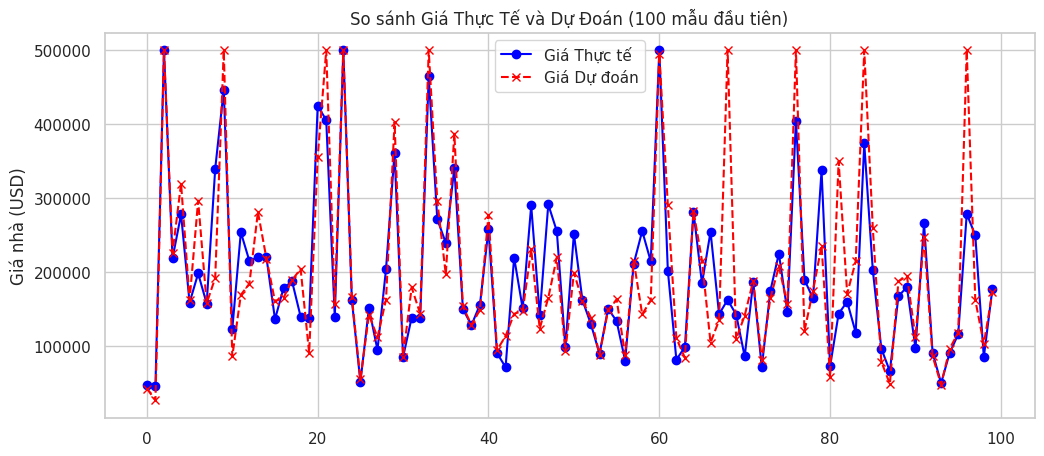

In [6]:
# Tính toán sai số
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DECISION TREE ---")
print(f"Mean Squared Error (MSE)      : {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Error (MAE)     : {mae:,.2f}")
print(f"Độ chính xác R-squared (R2)   : {r2:,.4f}")

# Vẽ đồ thị 100 căn nhà đầu tiên để so sánh trực quan thực tế vs dự đoán
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label='Giá Thực tế', marker='o', linestyle='-', color='blue')
plt.plot(y_pred[:100], label='Giá Dự đoán', marker='x', linestyle='--', color='red')
plt.title('So sánh Giá Thực Tế và Dự Đoán (100 mẫu đầu tiên)')
plt.ylabel('Giá nhà (USD)')
plt.legend()
plt.show()